# 6.9 - CertCF proximity metric diagnostics

This notebook isolates the effect of **how proximity is summarized** while keeping atlas construction fixed to standard class-wise `k`-medoids in input space.

All CertCF atlas build and query steps remain unchanged. The only quantities that change are the reported pilot-query distance summaries:

- standard mean input-space `L1`
- density-weighted mean of standard input-space `L1`
- density-adjusted per-query `L1`, defined as `L1 / density_weight`

The density-adjusted quantity is a **derived diagnostic metric**, not the original CertCF query objective.


In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import display
from sklearn.neighbors import NearestNeighbors

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from certcf import CertCFAtlas, NearestOppositeClassClearanceStrategy
from counterfactuals.benchmarks import create_default_registries
from counterfactuals.utils.clustering import select_prototype_indices
from scripts.benchmark import _build_query_tasks, _build_torch_model_from_checkpoint
from torch.utils.data import TensorDataset

sns.set_theme(style='whitegrid', context='talk')
np.set_printoptions(precision=4, suppress=True)


In [2]:
CONFIG_PATH = ROOT / 'configs/benchmarks/benchmark_meeting_all_200q.yaml'

DATASETS = ['adult']
SELECTION_METHOD = 'kmedoids_x'
SELECTION_LABEL = 'k-medoids in input space (X)'
SELECTION_SPACE = 'input_space'
K_GRID = [100, 200, 300, 500]
LIRPA_METHOD = 'backward'
CERTCF_PARAM_OVERRIDES = {
    'eps_alpha': 0.45,
}
LOW_MARGIN_QUANTILE = 0.10
MAX_COVERAGE_POINTS_PER_CLASS = 4000
COVERAGE_BATCH_SIZE = 128
PILOT_N_QUERIES = 25
WEIGHTED_KNN_K = 10
MARGIN_GAMMA = 5.0
VISUAL_K = 200
SEED = 42

print(CONFIG_PATH)
print(DATASETS)
print(SELECTION_METHOD)
print(K_GRID)
print(LIRPA_METHOD)
print(CERTCF_PARAM_OVERRIDES)
print({'weighted_knn_k': WEIGHTED_KNN_K, 'margin_gamma': MARGIN_GAMMA, 'visual_k': VISUAL_K})


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/configs/benchmarks/benchmark_meeting_all_200q.yaml
['adult']
kmedoids_x
[100, 200, 300, 500]
backward
{'eps_alpha': 0.45}
{'weighted_knn_k': 10, 'margin_gamma': 5.0, 'visual_k': 200}


In [3]:
with CONFIG_PATH.open() as f:
    BENCHMARK_CFG = yaml.safe_load(f)

DATASET_CFGS = {cfg['name']: cfg for cfg in BENCHMARK_CFG['datasets']}
SHARED_METHOD_CFGS = {cfg['name']: cfg for cfg in BENCHMARK_CFG['methods']}
REGISTRIES = create_default_registries()

missing = sorted(set(DATASETS).difference(DATASET_CFGS))
if missing:
    raise ValueError(f'Unknown datasets in DATASETS: {missing}')


def _merge_certcf_params(dataset_name):
    params = dict(SHARED_METHOD_CFGS['certcf'].get('params', {}))
    ds_overrides = DATASET_CFGS[dataset_name].get('method_overrides', {}).get('certcf', {})
    params.update(ds_overrides)
    params.update(CERTCF_PARAM_OVERRIDES)
    return params


def _resolve_lirpa_method(method_name):
    return str(method_name).strip().lower().replace('_', '-')


def _resolve_repo_path(path_value):
    path = Path(path_value)
    if path.is_absolute():
        return path
    candidates = [ROOT / path, Path.cwd() / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return (ROOT / path).resolve()


def _batched_logits(model_wrapper, x, batch_size=2048):
    module = model_wrapper.model.eval()
    device = torch.device(model_wrapper.device)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            x_batch = torch.from_numpy(np.asarray(x[start:start + batch_size], dtype=np.float32)).to(device)
            logits = module(x_batch).detach().cpu().numpy()
            outputs.append(logits)
    return np.concatenate(outputs, axis=0)


def _batched_predict_proba(model_wrapper, x, batch_size=2048):
    logits = _batched_logits(model_wrapper, x, batch_size=batch_size)
    logits = logits - logits.max(axis=1, keepdims=True)
    probs = np.exp(logits)
    probs /= probs.sum(axis=1, keepdims=True)
    return probs


def _margin_scores(logits, y_true):
    logits = np.asarray(logits, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.int64)
    true_scores = logits[np.arange(len(y_true)), y_true]
    masked = logits.copy()
    masked[np.arange(len(y_true)), y_true] = -np.inf
    other_scores = masked.max(axis=1)
    return true_scores - other_scores


def _split_indices_into_strata(cls_idx, margins):
    cls_idx = np.asarray(cls_idx, dtype=np.int64)
    ordered = cls_idx[np.argsort(margins[cls_idx], kind='stable')]
    splits = np.array_split(ordered, 3)
    return {
        'boundary': np.asarray(splits[0], dtype=np.int64),
        'intermediate': np.asarray(splits[1], dtype=np.int64),
        'interior': np.asarray(splits[2], dtype=np.int64),
    }


def _load_dataset_bundle(dataset_name):
    ds_cfg = DATASET_CFGS[dataset_name]
    dataset_params = dict(ds_cfg.get('dataset_params', {'data_dir': 'data/'}))
    dataset_params['data_dir'] = str(_resolve_repo_path(dataset_params.get('data_dir', 'data/')))
    dataset = REGISTRIES['dataset'].create(dataset_name, **dataset_params)
    dataset.load()

    x_train, y_train = dataset.get_train()
    x_test, y_test = dataset.get_test()
    model_cfg = ds_cfg['model']
    if model_cfg['name'] != 'tabular_classifier_ckpt':
        raise ValueError(f"This notebook only supports tabular checkpoint models, got {model_cfg['name']!r}.")

    model_params = dict(model_cfg.get('params', {}))
    model_params['checkpoint'] = str(_resolve_repo_path(model_params['checkpoint']))
    model = _build_torch_model_from_checkpoint(
        checkpoint=model_params['checkpoint'],
        device=model_params.get('device', 'cpu'),
        dataset_module=model_params.get('dataset_module', dataset_name),
        hidden_dims=list(model_params.get('hidden_dims', [32, 8])),
        dropout=float(model_params.get('dropout', 0.2)),
    )

    certcf_params = _merge_certcf_params(dataset_name)
    cert_norm = np.inf if str(certcf_params.get('norm', 2)).lower() in {'inf', 'infinity'} else int(certcf_params.get('norm', 2))
    distance_norm_raw = certcf_params.get('distance_norm', cert_norm)
    distance_norm = np.inf if str(distance_norm_raw).lower() in {'inf', 'infinity'} else int(distance_norm_raw)
    query_method = str(certcf_params.get('query_method', 'sorted')).lower()
    spec = getattr(dataset, 'spec', None)
    ohe_slices = list(spec.categorical_slices) if spec is not None and len(spec.categorical_slices) else None

    x_train = np.asarray(x_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.int64)
    x_test = np.asarray(x_test, dtype=np.float32)
    y_test = np.asarray(y_test, dtype=np.int64)

    logits = _batched_logits(model, x_train)
    train_probs = _batched_predict_proba(model, x_train)
    margins = _margin_scores(logits, y_train)

    return {
        'dataset_name': dataset_name,
        'dataset': dataset,
        'spec': spec,
        'x_train': x_train,
        'y_train': y_train,
        'train_probs': np.asarray(train_probs, dtype=np.float32),
        'x_test': x_test,
        'y_test': y_test,
        'model': model,
        'model_cfg': model_cfg,
        'certcf_params': certcf_params,
        'cert_norm': cert_norm,
        'distance_norm': distance_norm,
        'query_method': query_method,
        'ohe_slices': ohe_slices,
        'margin_scores': margins,
        'class_labels': [int(v) for v in np.unique(y_train)],
        'prototype_indices_cache': {},
        'atlas_cache': {},
        'class_strata_cache': {},
        'eval_indices_cache': {},
        'density_nn_cache': {},
    }


def _select_within_subset(space_subset, k):
    k = min(int(k), len(space_subset))
    if k <= 0:
        return np.array([], dtype=np.int64)
    if k == len(space_subset):
        return np.arange(len(space_subset), dtype=np.int64)
    return np.asarray(
        select_prototype_indices(space_subset, k=k, method='kmedoids', random_state=SEED),
        dtype=np.int64,
    )


def _summary_stats(values):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return {
            'n_points': 0,
            'mean_distance': np.nan,
            'median_distance': np.nan,
            'p90_distance': np.nan,
            'p95_distance': np.nan,
        }
    return {
        'n_points': int(len(values)),
        'mean_distance': float(np.mean(values)),
        'median_distance': float(np.median(values)),
        'p90_distance': float(np.quantile(values, 0.90)),
        'p95_distance': float(np.quantile(values, 0.95)),
    }


def _get_class_strata(bundle, class_label):
    cache = bundle['class_strata_cache']
    class_label = int(class_label)
    if class_label in cache:
        return cache[class_label]
    cls_idx = np.where(bundle['y_train'] == class_label)[0]
    strata = _split_indices_into_strata(cls_idx, bundle['margin_scores'])
    cache[class_label] = strata
    return strata


def _get_prototype_indices(bundle, k):
    cache = bundle['prototype_indices_cache']
    cache_key = int(k)
    if cache_key in cache:
        return cache[cache_key]

    selected = []
    for class_label in bundle['class_labels']:
        cls_idx = np.where(bundle['y_train'] == class_label)[0]
        k_cls = min(int(k), len(cls_idx))
        local_idx = _select_within_subset(bundle['x_train'][cls_idx], k_cls)
        selected.append(cls_idx[local_idx])

    absolute_idx = np.concatenate(selected).astype(np.int64)
    cache[cache_key] = absolute_idx
    return absolute_idx


def _build_certcf_atlas(bundle, k):
    cache = bundle['atlas_cache']
    cache_key = int(k)
    if cache_key in cache:
        return cache[cache_key]

    selected_idx = _get_prototype_indices(bundle, k)
    x_proto = bundle['x_train'][selected_idx]
    y_proto = bundle['y_train'][selected_idx]
    params = bundle['certcf_params']

    atlas = CertCFAtlas(
        model=bundle['model'].model,
        dataset=TensorDataset(torch.from_numpy(x_proto).float(), torch.from_numpy(y_proto).long()),
        device=bundle['model'].device,
        cnn=False,
        norm=bundle['cert_norm'],
        distance_norm=bundle['distance_norm'],
        eps_strategy=NearestOppositeClassClearanceStrategy(alpha=float(bundle['certcf_params'].get('eps_alpha', CERTCF_PARAM_OVERRIDES.get('eps_alpha', 0.25)))),
        batch_size=int(params.get('batch_size', 256)),
        ohe_slices=bundle['ohe_slices'],
        default_query_method=bundle['query_method'],
        solver_maxiter=int(params.get('solver_maxiter', 500)),
        lirpa_method=_resolve_lirpa_method(LIRPA_METHOD),
    )

    t0 = time.perf_counter()
    atlas.build(verbose=False)
    build_time_s = time.perf_counter() - t0
    cache[cache_key] = (atlas, build_time_s, selected_idx)
    return cache[cache_key]


def _get_eval_indices(bundle, class_label, max_points=MAX_COVERAGE_POINTS_PER_CLASS):
    cache_key = (int(class_label), int(max_points) if max_points is not None else None)
    cache = bundle['eval_indices_cache']
    if cache_key in cache:
        return cache[cache_key]

    cls_idx = np.where(bundle['y_train'] == int(class_label))[0]
    if max_points is not None and len(cls_idx) > max_points:
        rng = np.random.default_rng(SEED + 10_000 + int(class_label))
        eval_idx = np.sort(rng.choice(cls_idx, size=max_points, replace=False))
    else:
        eval_idx = cls_idx
    cache[cache_key] = eval_idx
    return eval_idx


def _certified_membership_mask(atlas, class_label, x_eval):
    x_eval = np.asarray(x_eval, dtype=np.float64)
    mask = np.zeros(len(x_eval), dtype=bool)
    for i, x in enumerate(x_eval):
        result = atlas.verify_counterfactual(x, int(class_label), delta=0.0)
        mask[i] = bool(result['in_certified_polytope'])
    return mask


def _certified_cover_counts(atlas, class_label, x_eval):
    bd = atlas.bounds[int(class_label)]
    counts = np.zeros(len(x_eval), dtype=np.int64)
    for anchor_idx in range(len(bd['X'])):
        for i, x in enumerate(x_eval):
            nominal_ok, _ = atlas._polytope_membership_for_anchor(
                np.asarray(x, dtype=np.float64),
                bd,
                anchor_idx,
                delta=0.0,
                robust_norm=atlas.norm,
            )
            if nominal_ok:
                counts[i] += 1
    return counts


def _selection_summary_rows(bundle, k):
    y_train = bundle['y_train']
    margins = bundle['margin_scores']
    selected_idx = _get_prototype_indices(bundle, k)

    total_counts = {'boundary': 0, 'intermediate': 0, 'interior': 0}
    for class_label in bundle['class_labels']:
        strata = _get_class_strata(bundle, int(class_label))
        class_selected = selected_idx[y_train[selected_idx] == int(class_label)]
        for name in total_counts:
            total_counts[name] += int(np.isin(class_selected, strata[name]).sum())

    return [{
        'dataset': bundle['dataset_name'],
        'selection_method': SELECTION_METHOD,
        'selection_label': SELECTION_LABEL,
        'selection_space': SELECTION_SPACE,
        'k_per_class': int(k),
        'n_selected_total': int(len(selected_idx)),
        'selected_margin_mean': float(np.mean(margins[selected_idx])) if len(selected_idx) else np.nan,
        'selected_margin_median': float(np.median(margins[selected_idx])) if len(selected_idx) else np.nan,
        'n_boundary': int(total_counts['boundary']),
        'n_intermediate': int(total_counts['intermediate']),
        'n_interior': int(total_counts['interior']),
    }]


def _coverage_rows(bundle, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, k)
    x_train = bundle['x_train']
    rows = []
    total_eval = 0
    total_covered = 0

    for class_label in bundle['class_labels']:
        eval_idx = _get_eval_indices(bundle, int(class_label))
        covered = _certified_membership_mask(atlas, int(class_label), x_train[eval_idx])
        total_eval += int(len(eval_idx))
        total_covered += int(covered.sum())
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': SELECTION_METHOD,
            'selection_label': SELECTION_LABEL,
            'selection_space': SELECTION_SPACE,
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_eval': int(len(eval_idx)),
            'n_covered': int(covered.sum()),
            'coverage_rate': float(covered.mean()),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })

    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': SELECTION_METHOD,
        'selection_label': SELECTION_LABEL,
        'selection_space': SELECTION_SPACE,
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_eval': int(total_eval),
        'n_covered': int(total_covered),
        'coverage_rate': float(total_covered / total_eval) if total_eval else np.nan,
        'build_time_s': float(build_time_s),
        'n_selected_total': int(len(selected_idx)),
    })
    return rows


def _overlap_rows(bundle, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, k)
    x_train = bundle['x_train']
    rows = []
    total_eval = 0
    total_cover_counts = []

    for class_label in bundle['class_labels']:
        eval_idx = _get_eval_indices(bundle, int(class_label))
        cover_counts = _certified_cover_counts(atlas, int(class_label), x_train[eval_idx])
        covered_mask = cover_counts > 0
        multi_mask = cover_counts >= 2
        overlap_excess = np.maximum(cover_counts - 1, 0)

        total_eval += int(len(eval_idx))
        total_cover_counts.append(cover_counts)
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': SELECTION_METHOD,
            'selection_label': SELECTION_LABEL,
            'selection_space': SELECTION_SPACE,
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_eval': int(len(eval_idx)),
            'covered_rate': float(covered_mask.mean()),
            'multi_cover_rate': float(multi_mask.mean()),
            'mean_cover_count': float(np.mean(cover_counts)),
            'mean_cover_count_if_covered': float(np.mean(cover_counts[covered_mask])) if covered_mask.any() else np.nan,
            'mean_overlap_excess': float(np.mean(overlap_excess)),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })

    merged = np.concatenate(total_cover_counts) if total_cover_counts else np.array([], dtype=np.int64)
    covered_mask = merged > 0
    multi_mask = merged >= 2
    overlap_excess = np.maximum(merged - 1, 0)
    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': SELECTION_METHOD,
        'selection_label': SELECTION_LABEL,
        'selection_space': SELECTION_SPACE,
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_eval': int(total_eval),
        'covered_rate': float(covered_mask.mean()) if len(merged) else np.nan,
        'multi_cover_rate': float(multi_mask.mean()) if len(merged) else np.nan,
        'mean_cover_count': float(np.mean(merged)) if len(merged) else np.nan,
        'mean_cover_count_if_covered': float(np.mean(merged[covered_mask])) if covered_mask.any() else np.nan,
        'mean_overlap_excess': float(np.mean(overlap_excess)) if len(merged) else np.nan,
        'build_time_s': float(build_time_s),
        'n_selected_total': int(len(selected_idx)),
    })
    return rows


def _nn_kwargs_for_norm(norm_value):
    if norm_value == 1:
        return {'metric': 'minkowski', 'p': 1}
    if norm_value == 2:
        return {'metric': 'minkowski', 'p': 2}
    if norm_value == np.inf:
        return {'metric': 'chebyshev'}
    raise ValueError(f'Unsupported norm for nearest-neighbor density estimation: {norm_value!r}')


def _get_density_reference_nn(bundle, target_class, knn_k=WEIGHTED_KNN_K):
    target_class = int(target_class)
    cache_key = (target_class, int(knn_k))
    cache = bundle['density_nn_cache']
    if cache_key in cache:
        return cache[cache_key]

    ref = bundle['x_train'][bundle['y_train'] == target_class]
    n_neighbors = min(len(ref), max(1, int(knn_k)))
    nn = NearestNeighbors(n_neighbors=n_neighbors, **_nn_kwargs_for_norm(bundle['distance_norm']))
    nn.fit(ref)
    cache[cache_key] = (nn, ref)
    return cache[cache_key]


def _density_raw_for_queries(bundle, x_queries, target_classes, knn_k=WEIGHTED_KNN_K):
    x_queries = np.asarray(x_queries, dtype=np.float64)
    target_classes = np.asarray(target_classes, dtype=np.int64)
    densities = np.full(len(x_queries), np.nan, dtype=np.float64)

    for class_label in np.unique(target_classes):
        mask = target_classes == int(class_label)
        nn, ref = _get_density_reference_nn(bundle, int(class_label), knn_k=knn_k)
        if len(ref) == 0:
            continue
        distances, _ = nn.kneighbors(x_queries[mask])
        kth_dist = distances[:, -1]
        densities[mask] = 1.0 / (kth_dist + 1e-12)
    return densities


def _margin_weight_raw(target_probs, gamma=MARGIN_GAMMA):
    target_probs = np.asarray(target_probs, dtype=np.float64)
    return np.exp(-float(gamma) * np.abs(target_probs - 0.5))


def _weighted_mean(values, weights):
    values = np.asarray(values, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not valid.any():
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))


def _pilot_query_rows(bundle, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, k)
    query_indices, y_true, y_orig, target_classes = _build_query_tasks(
        dataset_name=bundle['dataset_name'],
        x_test=bundle['x_test'],
        y_test=bundle['y_test'],
        model=bundle['model'],
        sampling_cfg={'n_queries': int(PILOT_N_QUERIES)},
        rng=np.random.default_rng(SEED),
    )

    if target_classes is None:
        n_classes = int(bundle['model'].predict_proba(bundle['x_test'][:1]).shape[1])
        if n_classes != 2:
            raise ValueError(
                f"Pilot query analysis requires explicit target classes for non-binary dataset {bundle['dataset_name']!r}."
            )
        target_classes = 1 - np.asarray(y_orig, dtype=np.int64)

    x_queries = bundle['x_test'][query_indices]
    source_probs = _batched_predict_proba(bundle['model'], x_queries)
    source_target_probs = source_probs[np.arange(len(target_classes)), np.asarray(target_classes, dtype=np.int64)]
    density_raw = _density_raw_for_queries(bundle, x_queries, target_classes, knn_k=WEIGHTED_KNN_K)
    margin_weight_raw = _margin_weight_raw(source_target_probs, gamma=MARGIN_GAMMA)

    rows = []
    for row_idx, (query_idx, y_true_i, y_orig_i, target_class) in enumerate(zip(query_indices, y_true, y_orig, target_classes)):
        result = atlas.find_counterfactual(
            x_query=bundle['x_test'][query_idx],
            target_class=int(target_class),
            method=bundle['query_method'],
        )
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': SELECTION_METHOD,
            'selection_label': SELECTION_LABEL,
            'selection_space': SELECTION_SPACE,
            'k_per_class': int(k),
            'query_idx': int(query_idx),
            'y_true': int(y_true_i),
            'y_orig': int(y_orig_i),
            'target_class': int(target_class),
            'source_target_prob': float(source_target_probs[row_idx]),
            'density_weight_raw': float(density_raw[row_idx]),
            'margin_weight_raw': float(margin_weight_raw[row_idx]),
            'success': bool(result.success),
            'distance': float(result.distance) if result.success else np.nan,
            'query_time_ms': float(result.profiling.get('total_time_ms', np.nan)),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })
    return rows


def _augment_pilot_df(pilot_df):
    pilot_df = pilot_df.copy()
    pilot_df['density_weight'] = np.nan
    pilot_df['margin_weight'] = np.nan
    pilot_df['density_adjusted_distance'] = np.nan

    group_cols = ['dataset', 'selection_method', 'k_per_class']
    for _, idx in pilot_df.groupby(group_cols).groups.items():
        idx = np.asarray(list(idx), dtype=np.int64)
        success_mask = pilot_df.loc[idx, 'success'].to_numpy(dtype=bool) & np.isfinite(pilot_df.loc[idx, 'distance'].to_numpy(dtype=np.float64))
        if not success_mask.any():
            continue
        success_idx = idx[success_mask]

        density_raw = pilot_df.loc[success_idx, 'density_weight_raw'].to_numpy(dtype=np.float64)
        density_norm = density_raw / np.mean(density_raw)
        pilot_df.loc[success_idx, 'density_weight'] = density_norm
        pilot_df.loc[success_idx, 'density_adjusted_distance'] = (
            pilot_df.loc[success_idx, 'distance'].to_numpy(dtype=np.float64) / density_norm
        )

        margin_raw = pilot_df.loc[success_idx, 'margin_weight_raw'].to_numpy(dtype=np.float64)
        margin_norm = margin_raw / np.mean(margin_raw)
        pilot_df.loc[success_idx, 'margin_weight'] = margin_norm

    return pilot_df


def _pilot_metric_table(pilot_df):
    rows = []
    group_cols = ['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class']
    for keys, group in pilot_df.groupby(group_cols, as_index=False):
        key_map = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
        success_group = group[group['success'] & group['distance'].notna()].copy()
        rows.append({
            **key_map,
            'success_rate': float(group['success'].mean()),
            'standard_mean_distance': float(success_group['distance'].mean()) if len(success_group) else np.nan,
            'standard_median_distance': float(success_group['distance'].median()) if len(success_group) else np.nan,
            'density_weighted_mean_distance': _weighted_mean(
                success_group['distance'].to_numpy(dtype=np.float64),
                success_group['density_weight'].to_numpy(dtype=np.float64),
            ),
            'density_adjusted_mean_distance': float(success_group['density_adjusted_distance'].mean()) if len(success_group) else np.nan,
            'density_adjusted_median_distance': float(success_group['density_adjusted_distance'].median()) if len(success_group) else np.nan,
            'margin_weighted_mean_distance': _weighted_mean(
                success_group['distance'].to_numpy(dtype=np.float64),
                success_group['margin_weight'].to_numpy(dtype=np.float64),
            ),
            'mean_density_weight_raw': float(success_group['density_weight_raw'].mean()) if len(success_group) else np.nan,
            'mean_density_weight': float(success_group['density_weight'].mean()) if len(success_group) else np.nan,
            'mean_query_time_ms': float(group['query_time_ms'].mean()),
            'median_query_time_ms': float(group['query_time_ms'].median()),
            'build_time_s': float(group['build_time_s'].mean()),
        })
    return pd.DataFrame(rows)


def _comparison_table(metric_table):
    comparison_df = metric_table.copy()
    comparison_df['delta_density_weighted_vs_standard'] = (
        comparison_df['density_weighted_mean_distance'] - comparison_df['standard_mean_distance']
    )
    comparison_df['delta_density_adjusted_vs_standard'] = (
        comparison_df['density_adjusted_mean_distance'] - comparison_df['standard_mean_distance']
    )
    return comparison_df


In [4]:
bundles = {dataset_name: _load_dataset_bundle(dataset_name) for dataset_name in DATASETS}

overview_rows = []
for dataset_name, bundle in bundles.items():
    class_counts = pd.Series(bundle['y_train']).value_counts().sort_index().to_dict()
    overview_rows.append({
        'dataset': dataset_name,
        'n_train': int(len(bundle['x_train'])),
        'n_test': int(len(bundle['x_test'])),
        'classes': class_counts,
        'input_dim': int(bundle['x_train'].shape[1]),
        'cert_norm': bundle['cert_norm'],
        'distance_norm': bundle['distance_norm'],
        'eps_alpha': float(bundle['certcf_params'].get('eps_alpha', CERTCF_PARAM_OVERRIDES.get('eps_alpha', 0.25))),
        'query_method': bundle['query_method'],
        'lirpa_method': _resolve_lirpa_method(LIRPA_METHOD),
        'selection_method': SELECTION_LABEL,
    })

display(pd.DataFrame(overview_rows))


,dataset,n_train,n_test,classes,input_dim,cert_norm,distance_norm,eps_alpha,query_method,lirpa_method,selection_method
0,adult,36178,4522,"{0: 27224, 1: 8954}",104,1,1,0.45,sorted,backward,k-medoids in input space (X)


## 1. Fixed-selector summary


In [5]:
selection_rows = []
for dataset_name, bundle in bundles.items():
    for k in K_GRID:
        selection_rows.extend(_selection_summary_rows(bundle, k))

selection_df = pd.DataFrame(selection_rows)
display(selection_df.sort_values(['dataset', 'k_per_class']))


,dataset,selection_method,selection_label,selection_space,k_per_class,n_selected_total,selected_margin_mean,selected_margin_median,n_boundary,n_intermediate,n_interior
0,adult,kmedoids_x,k-medoids in input space (X),input_space,100,200,1.670025,1.046338,69,73,58
1,adult,kmedoids_x,k-medoids in input space (X),input_space,200,400,1.579059,1.052959,146,146,108
2,adult,kmedoids_x,k-medoids in input space (X),input_space,300,600,1.504499,1.021446,230,225,145
3,adult,kmedoids_x,k-medoids in input space (X),input_space,500,1000,1.480234,0.967787,393,393,214


## 2. Certified atlas coverage and overlap

This section is contextual: atlas construction is unchanged, so these metrics help anchor the proximity analysis but are not the main target of this notebook.


In [6]:
coverage_rows = []
overlap_rows = []
for dataset_name, bundle in bundles.items():
    for k in K_GRID:
        coverage_rows.extend(_coverage_rows(bundle, k))
        overlap_rows.extend(_overlap_rows(bundle, k))

coverage_df = pd.DataFrame(coverage_rows)
overlap_df = pd.DataFrame(overlap_rows)
coverage_overall = coverage_df[coverage_df['class_label'].eq('overall')].copy()
overlap_overall = overlap_df[overlap_df['class_label'].eq('overall')].copy()

display(coverage_overall.sort_values(['dataset', 'k_per_class']))
display(overlap_overall.sort_values(['dataset', 'k_per_class']))


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:11<00:00,  5.95s/it]


,dataset,selection_method,selection_label,selection_space,class_label,k_per_class,n_eval,n_covered,coverage_rate,build_time_s,n_selected_total
2,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,100,8000,241,0.030125,2.625510,200
5,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,200,8000,332,0.041500,4.896450,400
8,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,300,8000,386,0.048250,7.550058,600
11,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,500,8000,517,0.064625,11.931391,1000


,dataset,selection_method,selection_label,selection_space,class_label,k_per_class,n_eval,covered_rate,multi_cover_rate,mean_cover_count,mean_cover_count_if_covered,mean_overlap_excess,build_time_s,n_selected_total
2,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,100,8000,0.030125,0.003875,0.038000,1.261411,0.007875,2.625510,200
5,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,200,8000,0.041500,0.003500,0.051875,1.250000,0.010375,4.896450,400
8,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,300,8000,0.048250,0.006750,0.061875,1.282383,0.013625,7.550058,600
11,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,500,8000,0.064625,0.013875,0.116500,1.802708,0.051875,11.931391,1000


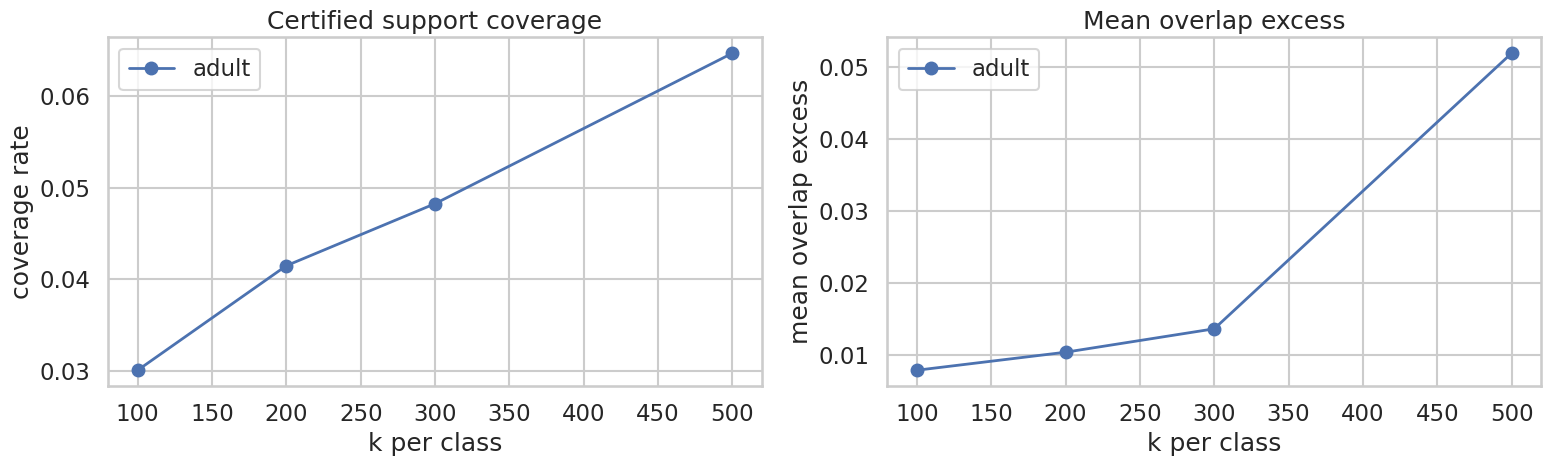

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
for dataset_name in DATASETS:
    df_cov = coverage_overall[coverage_overall['dataset'] == dataset_name].sort_values('k_per_class')
    df_ov = overlap_overall[overlap_overall['dataset'] == dataset_name].sort_values('k_per_class')
    axes[0].plot(df_cov['k_per_class'], df_cov['coverage_rate'], marker='o', linewidth=2, label=dataset_name)
    axes[1].plot(df_ov['k_per_class'], df_ov['mean_overlap_excess'], marker='o', linewidth=2, label=dataset_name)

axes[0].set_title('Certified support coverage')
axes[0].set_xlabel('k per class')
axes[0].set_ylabel('coverage rate')
axes[1].set_title('Mean overlap excess')
axes[1].set_xlabel('k per class')
axes[1].set_ylabel('mean overlap excess')
for ax in axes:
    ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## 3. Proximity metric diagnostics

The density-adjusted distance below is a **derived diagnostic metric**. It does not replace the original CertCF query objective; it only re-expresses returned input-space `L1` distances after normalizing by query density.


In [8]:
pilot_rows = []
for dataset_name, bundle in bundles.items():
    for k in K_GRID:
        pilot_rows.extend(_pilot_query_rows(bundle, k))

pilot_df = pd.DataFrame(pilot_rows)
pilot_aug_df = _augment_pilot_df(pilot_df)
metric_table = _pilot_metric_table(pilot_aug_df)

display(metric_table.sort_values(['dataset', 'k_per_class']))

max_weighted_diff = float(np.nanmax(np.abs(metric_table['density_weighted_mean_distance'] - metric_table['standard_mean_distance'])))
max_adjusted_diff = float(np.nanmax(np.abs(metric_table['density_adjusted_mean_distance'] - metric_table['standard_mean_distance'])))
if max_weighted_diff < 1e-6:
    print('Warning: density-weighted mean L1 is numerically almost identical to standard mean L1 in this run.')
else:
    print({'max_abs_difference_density_weighted_vs_standard': max_weighted_diff})

if max_adjusted_diff > 0.25:
    print('Note: density-adjusted L1 differs materially from standard L1 in this run; treat it as a derived diagnostic metric, not as the original CertCF objective.')


/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more in

,dataset,selection_method,selection_label,selection_space,k_per_class,success_rate,standard_mean_distance,standard_median_distance,density_weighted_mean_distance,density_adjusted_mean_distance,density_adjusted_median_distance,margin_weighted_mean_distance,mean_density_weight_raw,mean_density_weight,mean_query_time_ms,median_query_time_ms,build_time_s
0,adult,kmedoids_x,k-medoids in input space (X),input_space,100,1.0,10.133099,11.148364,8.738902,14.135236,13.899351,8.813853,0.217796,1.0,1539.102748,957.519751,2.625510
1,adult,kmedoids_x,k-medoids in input space (X),input_space,200,1.0,8.929708,9.407626,7.468637,12.619564,11.499814,7.532396,0.217796,1.0,2087.465879,1898.643681,4.896450
2,adult,kmedoids_x,k-medoids in input space (X),input_space,300,1.0,8.725187,9.046485,7.311943,12.349487,11.538538,7.338934,0.217796,1.0,4119.465252,3986.378767,7.550058
3,adult,kmedoids_x,k-medoids in input space (X),input_space,500,1.0,8.255779,8.740889,6.993435,11.622245,10.222320,7.185113,0.217796,1.0,4480.225010,5148.121829,11.931391


{'max_abs_difference_density_weighted_vs_standard': 1.4610708536824006}
Note: density-adjusted L1 differs materially from standard L1 in this run; treat it as a derived diagnostic metric, not as the original CertCF objective.


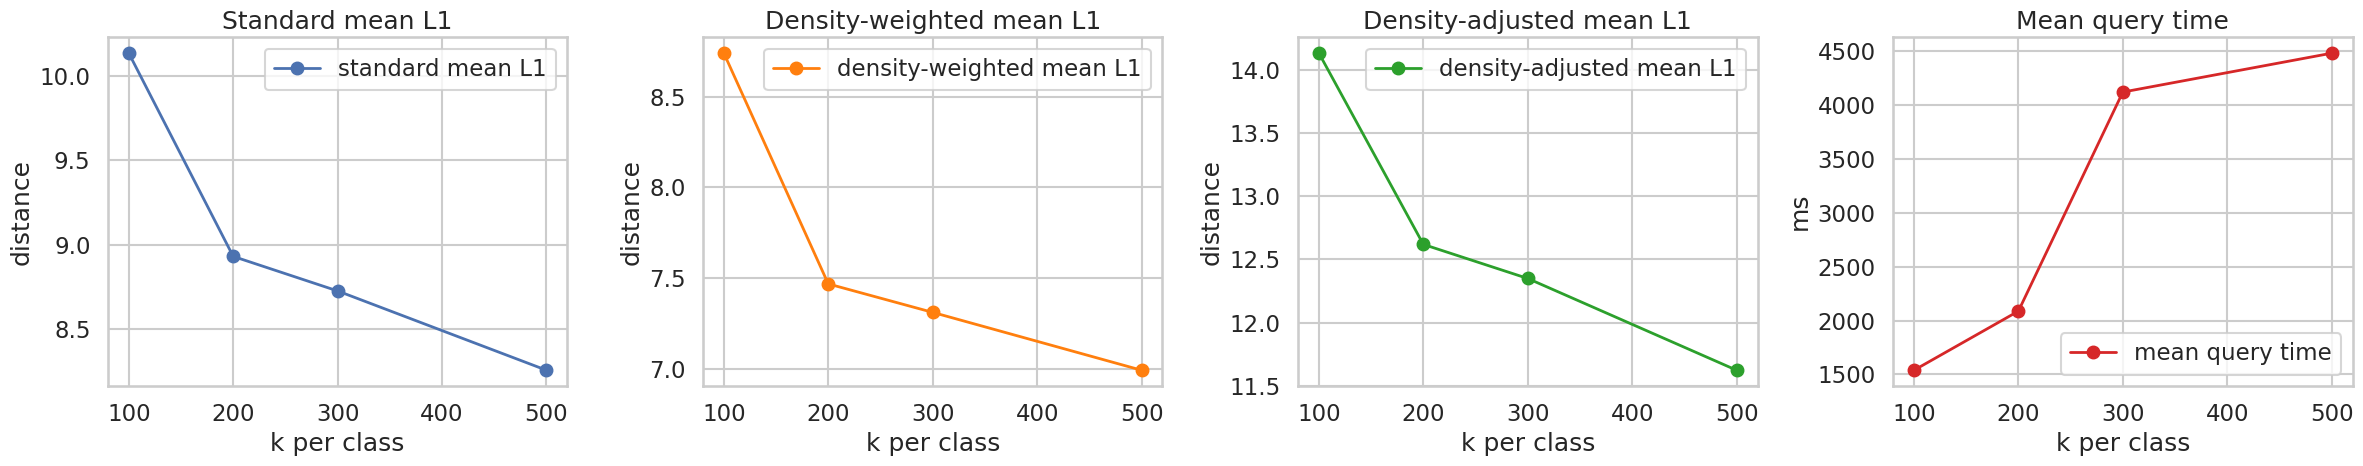

In [9]:
plot_df = metric_table.sort_values('k_per_class')
fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharex=True)
axes[0].plot(plot_df['k_per_class'], plot_df['standard_mean_distance'], marker='o', linewidth=2, label='standard mean L1')
axes[1].plot(plot_df['k_per_class'], plot_df['density_weighted_mean_distance'], marker='o', linewidth=2, color='tab:orange', label='density-weighted mean L1')
axes[2].plot(plot_df['k_per_class'], plot_df['density_adjusted_mean_distance'], marker='o', linewidth=2, color='tab:green', label='density-adjusted mean L1')
axes[3].plot(plot_df['k_per_class'], plot_df['mean_query_time_ms'], marker='o', linewidth=2, color='tab:red', label='mean query time')

titles = [
    'Standard mean L1',
    'Density-weighted mean L1',
    'Density-adjusted mean L1',
    'Mean query time',
]
ylabels = ['distance', 'distance', 'distance', 'ms']
for ax, title, ylabel in zip(axes, titles, ylabels):
    ax.set_title(title)
    ax.set_xlabel('k per class')
    ax.set_ylabel(ylabel)
    ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## 4. Pilot query diagnostics


In [10]:
display(
    metric_table.sort_values(['dataset', 'k_per_class'])[[
        'dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class',
        'success_rate', 'mean_query_time_ms', 'median_query_time_ms', 'build_time_s',
        'margin_weighted_mean_distance'
    ]]
)


,dataset,selection_method,selection_label,selection_space,k_per_class,success_rate,mean_query_time_ms,median_query_time_ms,build_time_s,margin_weighted_mean_distance
0,adult,kmedoids_x,k-medoids in input space (X),input_space,100,1.0,1539.102748,957.519751,2.625510,8.813853
1,adult,kmedoids_x,k-medoids in input space (X),input_space,200,1.0,2087.465879,1898.643681,4.896450,7.532396
2,adult,kmedoids_x,k-medoids in input space (X),input_space,300,1.0,4119.465252,3986.378767,7.550058,7.338934
3,adult,kmedoids_x,k-medoids in input space (X),input_space,500,1.0,4480.225010,5148.121829,11.931391,7.185113


## 5. Comparison table across metrics


In [11]:
comparison_df = _comparison_table(metric_table)

display(comparison_df.sort_values(['dataset', 'k_per_class'])[[
    'dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class',
    'standard_mean_distance', 'density_weighted_mean_distance', 'density_adjusted_mean_distance',
    'standard_median_distance', 'density_adjusted_median_distance',
    'success_rate', 'mean_query_time_ms', 'build_time_s',
    'delta_density_weighted_vs_standard', 'delta_density_adjusted_vs_standard'
]])


,dataset,selection_method,selection_label,selection_space,k_per_class,standard_mean_distance,density_weighted_mean_distance,density_adjusted_mean_distance,standard_median_distance,density_adjusted_median_distance,success_rate,mean_query_time_ms,build_time_s,delta_density_weighted_vs_standard,delta_density_adjusted_vs_standard
0,adult,kmedoids_x,k-medoids in input space (X),input_space,100,10.133099,8.738902,14.135236,11.148364,13.899351,1.0,1539.102748,2.625510,-1.394198,4.002137
1,adult,kmedoids_x,k-medoids in input space (X),input_space,200,8.929708,7.468637,12.619564,9.407626,11.499814,1.0,2087.465879,4.896450,-1.461071,3.689856
2,adult,kmedoids_x,k-medoids in input space (X),input_space,300,8.725187,7.311943,12.349487,9.046485,11.538538,1.0,4119.465252,7.550058,-1.413245,3.624300
3,adult,kmedoids_x,k-medoids in input space (X),input_space,500,8.255779,6.993435,11.622245,8.740889,10.222320,1.0,4480.225010,11.931391,-1.262344,3.366466


## 6. Lightweight visual diagnostics


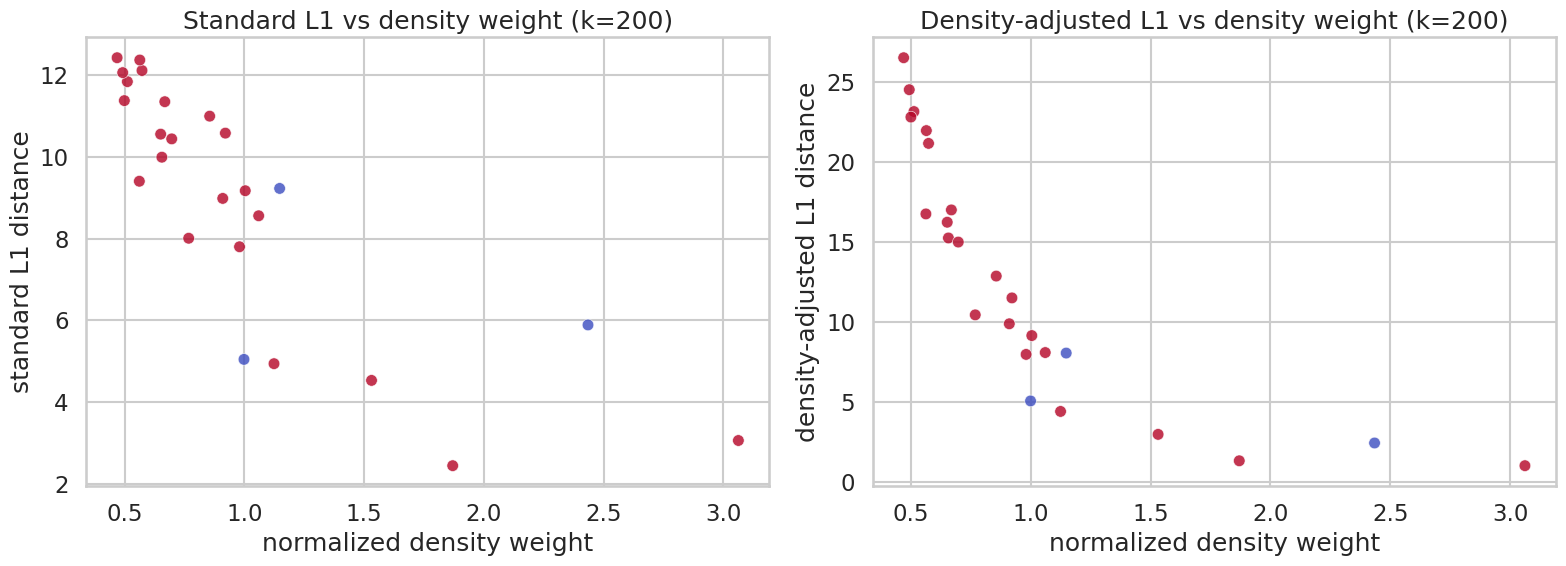

In [12]:
visual_k = VISUAL_K if VISUAL_K in set(metric_table['k_per_class']) else int(metric_table['k_per_class'].iloc[0])
scatter_df = pilot_aug_df[(pilot_aug_df['k_per_class'] == visual_k) & pilot_aug_df['success'] & pilot_aug_df['distance'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
axes[0].scatter(
    scatter_df['density_weight'],
    scatter_df['distance'],
    s=70,
    alpha=0.8,
    c=scatter_df['target_class'],
    cmap='coolwarm',
    edgecolors='white',
    linewidths=0.5,
)
axes[0].set_title(f'Standard L1 vs density weight (k={visual_k})')
axes[0].set_xlabel('normalized density weight')
axes[0].set_ylabel('standard L1 distance')

axes[1].scatter(
    scatter_df['density_weight'],
    scatter_df['density_adjusted_distance'],
    s=70,
    alpha=0.8,
    c=scatter_df['target_class'],
    cmap='coolwarm',
    edgecolors='white',
    linewidths=0.5,
)
axes[1].set_title(f'Density-adjusted L1 vs density weight (k={visual_k})')
axes[1].set_xlabel('normalized density weight')
axes[1].set_ylabel('density-adjusted L1 distance')

plt.tight_layout()
plt.show()
